In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import time
import math
import random
import numpy as np
from scipy.stats import norm
import pylab as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import os
import glob
from functools import partial
from IPython.display import display, clear_output
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from PIL import Image
from tqdm import tqdm

torch.set_default_dtype(torch.float32)
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cpu')


cuda = torch.cuda.is_available()
if cuda:
    torch.cuda.manual_seed(42)
    device = torch.device('cuda')

input_shape = (64, 64)  # (h, w)

In [2]:
class Visualizer(object):
    def __init__(self,
                 figsize,
                 loss_xlim=None,
                 loss_ylim=None,
                 plot_interval=1):
        self.loss_xlim = loss_xlim
        self.loss_ylim = loss_ylim
        self.plot_interval = plot_interval
        sns.set()
        self.fig = plt.figure(figsize=figsize)
        self.rows, self.cols = 4, 4

    def plot_subgrid(self, gs, images, title):
        outer_ax = plt.subplot(gs)
        outer_ax.set_title(title)
        outer_ax.set_xticks([])
        outer_ax.set_yticks([])

        inner_grid = gridspec.GridSpecFromSubplotSpec(
            self.rows, self.cols, subplot_spec=gs, wspace=.1, hspace=.1)

        for i, image in enumerate(images[:(self.rows * self.cols)]):
            ax = plt.Subplot(self.fig, inner_grid[i])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect('equal')
            ax.imshow(image.cpu().permute(1, 2, 0).numpy())
            self.fig.add_subplot(ax)

    def plot(self, x, x_recon, x_gen, z, loss_dict):
        
        gs = gridspec.GridSpec(2, 4, wspace=.2, hspace=.2,
                               height_ratios=(2, 1.5))

        self.plot_subgrid(gs[0], x, 'data')
        self.plot_subgrid(gs[1], x_recon, 'reconstructed data')
        self.plot_subgrid(gs[2], x_gen, 'generated samples')

        ax_z = plt.subplot(gs[3])
        
        ax_z.scatter(z[:, 0], z[:, 1], 1)
        ax_z.set_title('latent samples')
        ax_z.set_aspect('equal', adjustable='datalim')

        ax_trace = plt.subplot(gs[1, :])
        ax_trace.set_ylabel('loss')
        ax_trace.set_xlabel('epochs')
        if self.loss_xlim is not None:
            ax_trace.set_xlim(self.loss_xlim)
        if self.loss_ylim is not None:
            ax_trace.set_ylim(self.loss_ylim)
        for label, loss in loss_dict.items():
            plot_iter = np.arange(len(loss)) * self.plot_interval
            ax_trace.plot(plot_iter, loss, '-', label=label)
        if len(loss_dict) > 1:
            ax_trace.legend(ncol=len(loss_dict), loc='upper center')
        self.draw()

    def draw(self):
        clear_output(wait=True)
        display(self.fig)

In [3]:
def plot_image(image):
    
    plt.figure()
    plt.imshow(image.cpu().permute(1, 2, 0).numpy())
    plt.grid('off')
    plt.axis('off')
    plt.show()

No. of images in (our) CelebA dataset: 50000
Example Image with shape torch.Size([3, 64, 64]):


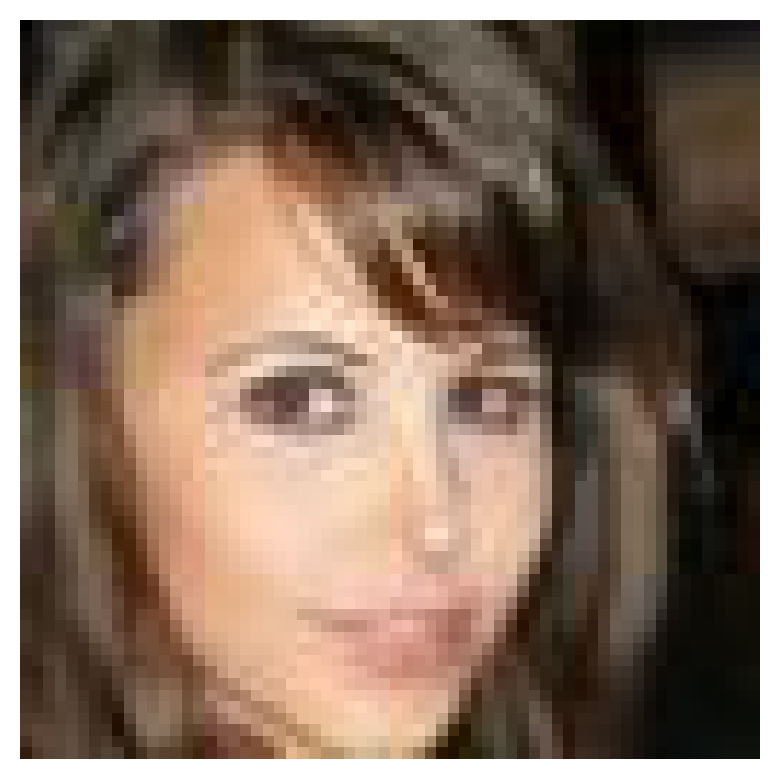

In [4]:
class CelebA_50k(Dataset):
    def __init__(self, root, train=True, transform=None):
        self.train = train
        self.transform = transform
        self.img_list = glob.glob(os.path.join(root, '*.jpg'))
        
    def __len__(self):
        return len(self.img_list)
    
    def __getitem__(self, idx):
        img_path = self.img_list[idx]
        img = Image.open(img_path)
        if self.transform is not None:
            img = self.transform(img)
        return img


data = CelebA_50k('/kaggle/input/50k-celeba-dataset-64x64/50k', transform=transforms.ToTensor())
print(f"No. of images in (our) CelebA dataset: {len(data)}")

test_image = data[random.randint(0, len(data))]
print(f"Example Image with shape {test_image.shape}:")
plot_image(test_image)

In [5]:
class Encoder(nn.Module):
    
    def __init__(self, input_features, latent_features):
        super(Encoder, self).__init__()

        self.input_features = input_features
        self.latent_features = latent_features
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1)  # output shape: (32, 32, 32)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)  # output shape: (64, 16, 16)
        self.relu2 = nn.ReLU(inplace=True)
        self.flatten = nn.Flatten()  # output shape: (64*16*16,)
        self.fc1 = nn.Linear(64*16*16, 256)  # output shape: (256,)
        self.relu3 = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(256, latent_features)
        
        

        

    def forward(self, x):
        
        x = x.view(-1, 3, 64, 64);

        x = self.conv1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu3(x)
        out = self.fc2(x)
        
        
        
        
        return out

In [6]:

input_features = 3*64*64
latent_features = 32

encoder = Encoder(input_features, latent_features)
# sample input
x = torch.rand((100, 3, 64, 64))
# forward pass through encoder
z = encoder(x)
print(f"Input shape: {x.shape},\nZ shape: {z.shape}")
print("The expected size of the z vector is (batch_size, 32). Is it?")

Input shape: torch.Size([100, 3, 64, 64]),
Z shape: torch.Size([100, 32])
The expected size of the z vector is (batch_size, 32). Is it?


In [7]:
class Decoder(nn.Module):
    """This is the decoder class for your Autoencoder. The objective of the decoder is to take a 
    compressed representation (latent code) vector `z` of size (N, latent_features) and transform 
    it to an image tensor of size (N, 3, 64, 64), where N=batch_size.
    
    You can use a combination of `nn.Linear` and `nn.ConvTranspose2d` layers here, with `nn.ReLU` activations
    in between (everywhere but the end). We used 2 Linear layers followed by 2 ConvTranspose2d layers in our 
    testing, but you can use anything as long as the input and output shapes are accounted for. Make sure you 
    `unflatten` the output of a linear layer before passing it as an input to conv2d layer (if any).

    Tip: Writing the expected input and output shapes after each layer in the comments helps.    
    """
    def __init__(self, output_features, latent_features):
        super(Decoder, self).__init__()
        self.output_features = output_features  # this is the product of output dimensions, not the shape
        self.latent_features = latent_features
        # TODO: initialize the Decoder network
        ####################################################
        self.fc1 = nn.Linear(latent_features, 256)
        self.relu1 = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(256, 64*16*16)
        self.relu2 = nn.ReLU(inplace=True)
        self.unflatten = nn.Unflatten(1, (64, 16, 16))
        self.conv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.relu3 = nn.ReLU(inplace=True)
        self.conv2 = nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1)
        
        
        
        ####################################################

    def forward(self, z):
        # TODO: Define the forward pass for the network, 
        # you can reuse 'z' for the output
        ####################################################
        z = self.fc1(z)
        z = self.relu1(z)
        z = self.fc2(z)
        z = self.relu2(z)
        z = self.unflatten(z)
        z = self.conv1(z)
        z = self.relu3(z)
        z = self.conv2(z)
        
        
        
        
        ####################################################
        return z

In [8]:
# let's test if it worked
output_features = 3*64*64
latent_features = 32
# initialize decoder
decoder = Decoder(output_features, latent_features)
# sample input
z = torch.rand((100, 32))
# forward pass through decoder
x_recon = decoder(z)
print(f"Input shape: {z.shape} \nOutput shape: {x_recon.shape}")
print("The expected size of the output is (batch_size, 3, 64, 64). Is it?")

Input shape: torch.Size([100, 32]) 
Output shape: torch.Size([100, 3, 64, 64])
The expected size of the output is (batch_size, 3, 64, 64). Is it?


In [9]:
class Autoencoder(nn.Module):

    """This will combine your encoder and decoder modules together
    with their powers combined and make an AUTOENCODER. We will also define loss functions here.
    You can choose any loss that compares the input and output directly, such as MSE, MAE, etc.
    
    Params:
        input_features   : the total number of input features to the network (int)
        latent_features  : the dimensionality of the latent code (compressed representation) (int)

    Inputs:
        X                : The input image. shape (N, 3, 64, 64)
        
    Outputs (dict):
        z                : The reparameterized sample produced by encoder. shape (N, latent_features)
        x_recon          : The reconstructed version of input X. shape (N, 3, 64, 64)
        loss             : reconstruction loss. (float)
    """

    def __init__(self, input_features, latent_features):
        super().__init__()
        
        self.input_features = self.output_features = input_features
        self.latent_features = latent_features

        self.encoder = Encoder(self.input_features, self.latent_features)
        self.decoder = Decoder(self.output_features, self.latent_features)
        self.relu = nn.ReLU()
        
        # TODO: fill out your chosen loss function here
        #############################################
        self.loss = nn.MSELoss()
        #############################################

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(self.relu(z))
        loss = self.loss(x_recon, x)
        
        # .detach() just makes it so the backprop is cutoff here (anything we do past it won't affect the gradient)
        
        return {
            'z': z.detach(),  # this contains the latent encodings that we'll use to plot
            'x_recon': x_recon.detach(),  # this contains the reconstructed image
            'loss': loss,  # this is the loss that we'll use to train the network through backprop
        }

In [10]:
# initialize model and count number of trainable parameters
input_features = 3*64*64
latent_features = 32
model = Autoencoder(input_features, latent_features)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"No. of trainable parameters: {num_params}")
print("Warning! If your model has > 0.5M params, it might take really long to train!")

No. of trainable parameters: 8460643
Warning! If your model has > 0.5M params, it might take really long to train!


Test image input:


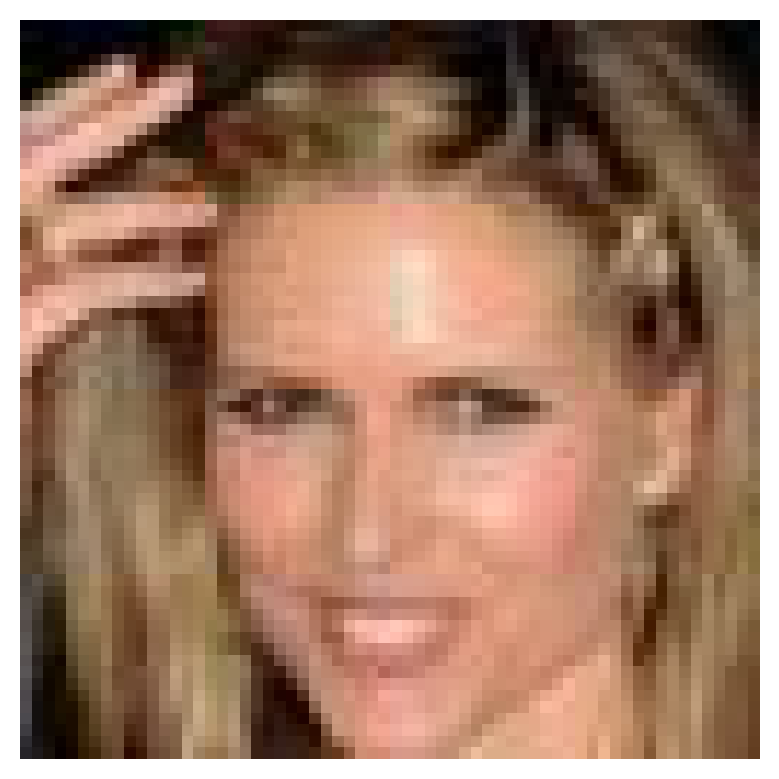

Test image reconstruction:


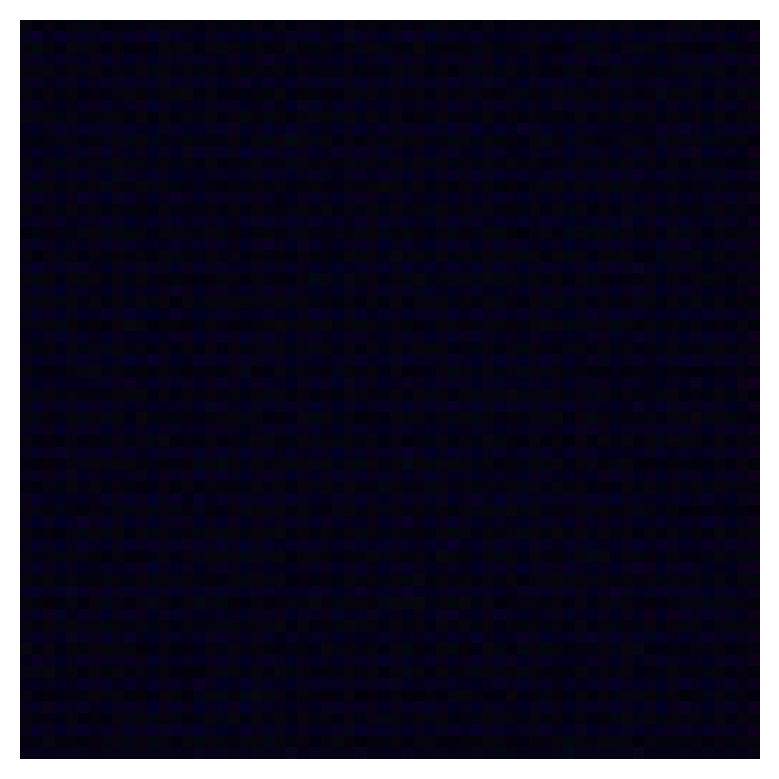

In [11]:
# Shows the prediction of the autoencoder without training

test_image = data[random.randint(0, len(data))]

print("Test image input:")
plot_image(test_image)

outputs = model(test_image.unsqueeze(0))

print("Test image reconstruction:")
plot_image(outputs['x_recon'].squeeze())

In [12]:
# Model and training parameters
input_features = 3 * 64 * 64  # do not change
# start with these parameters, and then play around with them
#############################################
latent_features = 10
lr = 1e-3
batch_size = 128
num_epochs = 20
#############################################

# Initialize model and move it to GPU
model = Autoencoder(input_features, latent_features)
model = model.to(device)

# Initialize dataset and dataloaders
# for this HW, we're gonna use a subset of the training data as test
# This is a really bad idea in practice, but sufficient for the purposes of this HW.
data = CelebA_50k('/kaggle/input/50k-celeba-dataset-64x64/50k', transform=transforms.ToTensor())
train_loader = DataLoader(data, batch_size=batch_size, num_workers=4, shuffle=True, pin_memory=True)
val_loader = DataLoader(data, batch_size=2000, num_workers=1, shuffle=False, pin_memory=True)

# Initialize optimizer, you can use SGD, Adam, or anything else here
optimizer = optim.Adam(model.parameters(), lr=lr)

In [13]:
# Let's take things for a spin
# This checks that your model, loss and optimizer are valid
print("BEFORE GRADIENT STEP:")
test_image = data[random.randint(0, len(data))]
# we now need to move the input to the same device as the model (aka GPU)
test_image = test_image.unsqueeze(0).to(device)
output = model(test_image)

optimizer.zero_grad() # Sets the gradient to 0 so that gradients don't stack together

loss_before = output['loss']
print("loss: ", loss_before.item())

loss_before.backward() # This gets the gradient of the loss function w.r.t all of your model's params

print()
print("AFTER GRADIENT STEP:")
optimizer.step() # This takes the step to train

output = model(test_image)

loss_after = output['loss']
print("loss: ",loss_after.item())

print()
print("Difference in loss:", (loss_before - loss_after).item())
print("This should be some positive number to say we reduced loss")

BEFORE GRADIENT STEP:
loss:  0.18687115609645844

AFTER GRADIENT STEP:
loss:  0.18134908378124237

Difference in loss: 0.0055220723152160645
This should be some positive number to say we reduced loss


In [14]:
def train_autoencoder(model, train_loader, val_loader, optimizer, epochs=1, seed=42):
    """Updates the parameters of the given model using the optimizer of choice to
    reduce the given loss_function. This will iterate over the dataloader `epochs` times
    training on each batch of images.
    
    There are 4 steps you need to complete here:
        (1) Reset the optimizer, so that gradients are zeroed out. Hint: use .zero_grad()
        (2) Forward pass: call the model on a batch of inputs `batch_x`.
        (3) Backward pass: use the `loss` key in the returned dict. Hint: use .backward()
        (4) Take a step in the direction of the -ve gradient. Hint: use .step()
    """
    torch.manual_seed(seed)
    if cuda:
        torch.cuda.manual_seed(seed)

    # set up tracking parameters
    plot_interval = 1
    history = {'loss': [],}
    vis = Visualizer(
        figsize=(16, 7),
        loss_xlim=(0, epochs),
        plot_interval=plot_interval,
    )
    
    # run the training loop
    print("Started training... (first epoch can take a while)")
    for epoch in range(epochs):
        model = model.train()  # set the model to training mode
        for batch_idx, batch_x in (enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"))):
            batch_x = batch_x.to(device)  # ensures the input is on the same device as the model
            # TODO Complete the training loop using the instructions above
            # Hint: the following code essentially does one training step
            #############################################
            optimizer.zero_grad()
            pred = model(batch_x)
            loss = pred['loss']
            loss.backward()
            optimizer.step()
            
            
            
            
            #############################################

        # validation
        if epoch % plot_interval == 0:
            test_autoencoder(model, val_loader, history, vis)
            
    return model


@torch.no_grad()  # this makes sure that we don't accumulate gradients during testing phase
def test_autoencoder(model, val_loader, history, vis):
    model = model.eval()  # set the model to evaluation mode
    batch_x = next(iter(val_loader)).to(device)  # only use 2000 examples for test
    
    loss_dict = model(batch_x)  # run forward pass on test examples
    
    # record metrics and images for plotting
    history['loss'].append(loss_dict['loss'].item())
    x_recon = loss_dict['x_recon']

    # generate faces -- or atleast try
    x_gen = model.decoder(torch.relu(torch.randn_like(loss_dict['z'])))

    # plot the results
    vis.plot(batch_x, x_recon, x_gen, loss_dict['z'].cpu().numpy(), history)

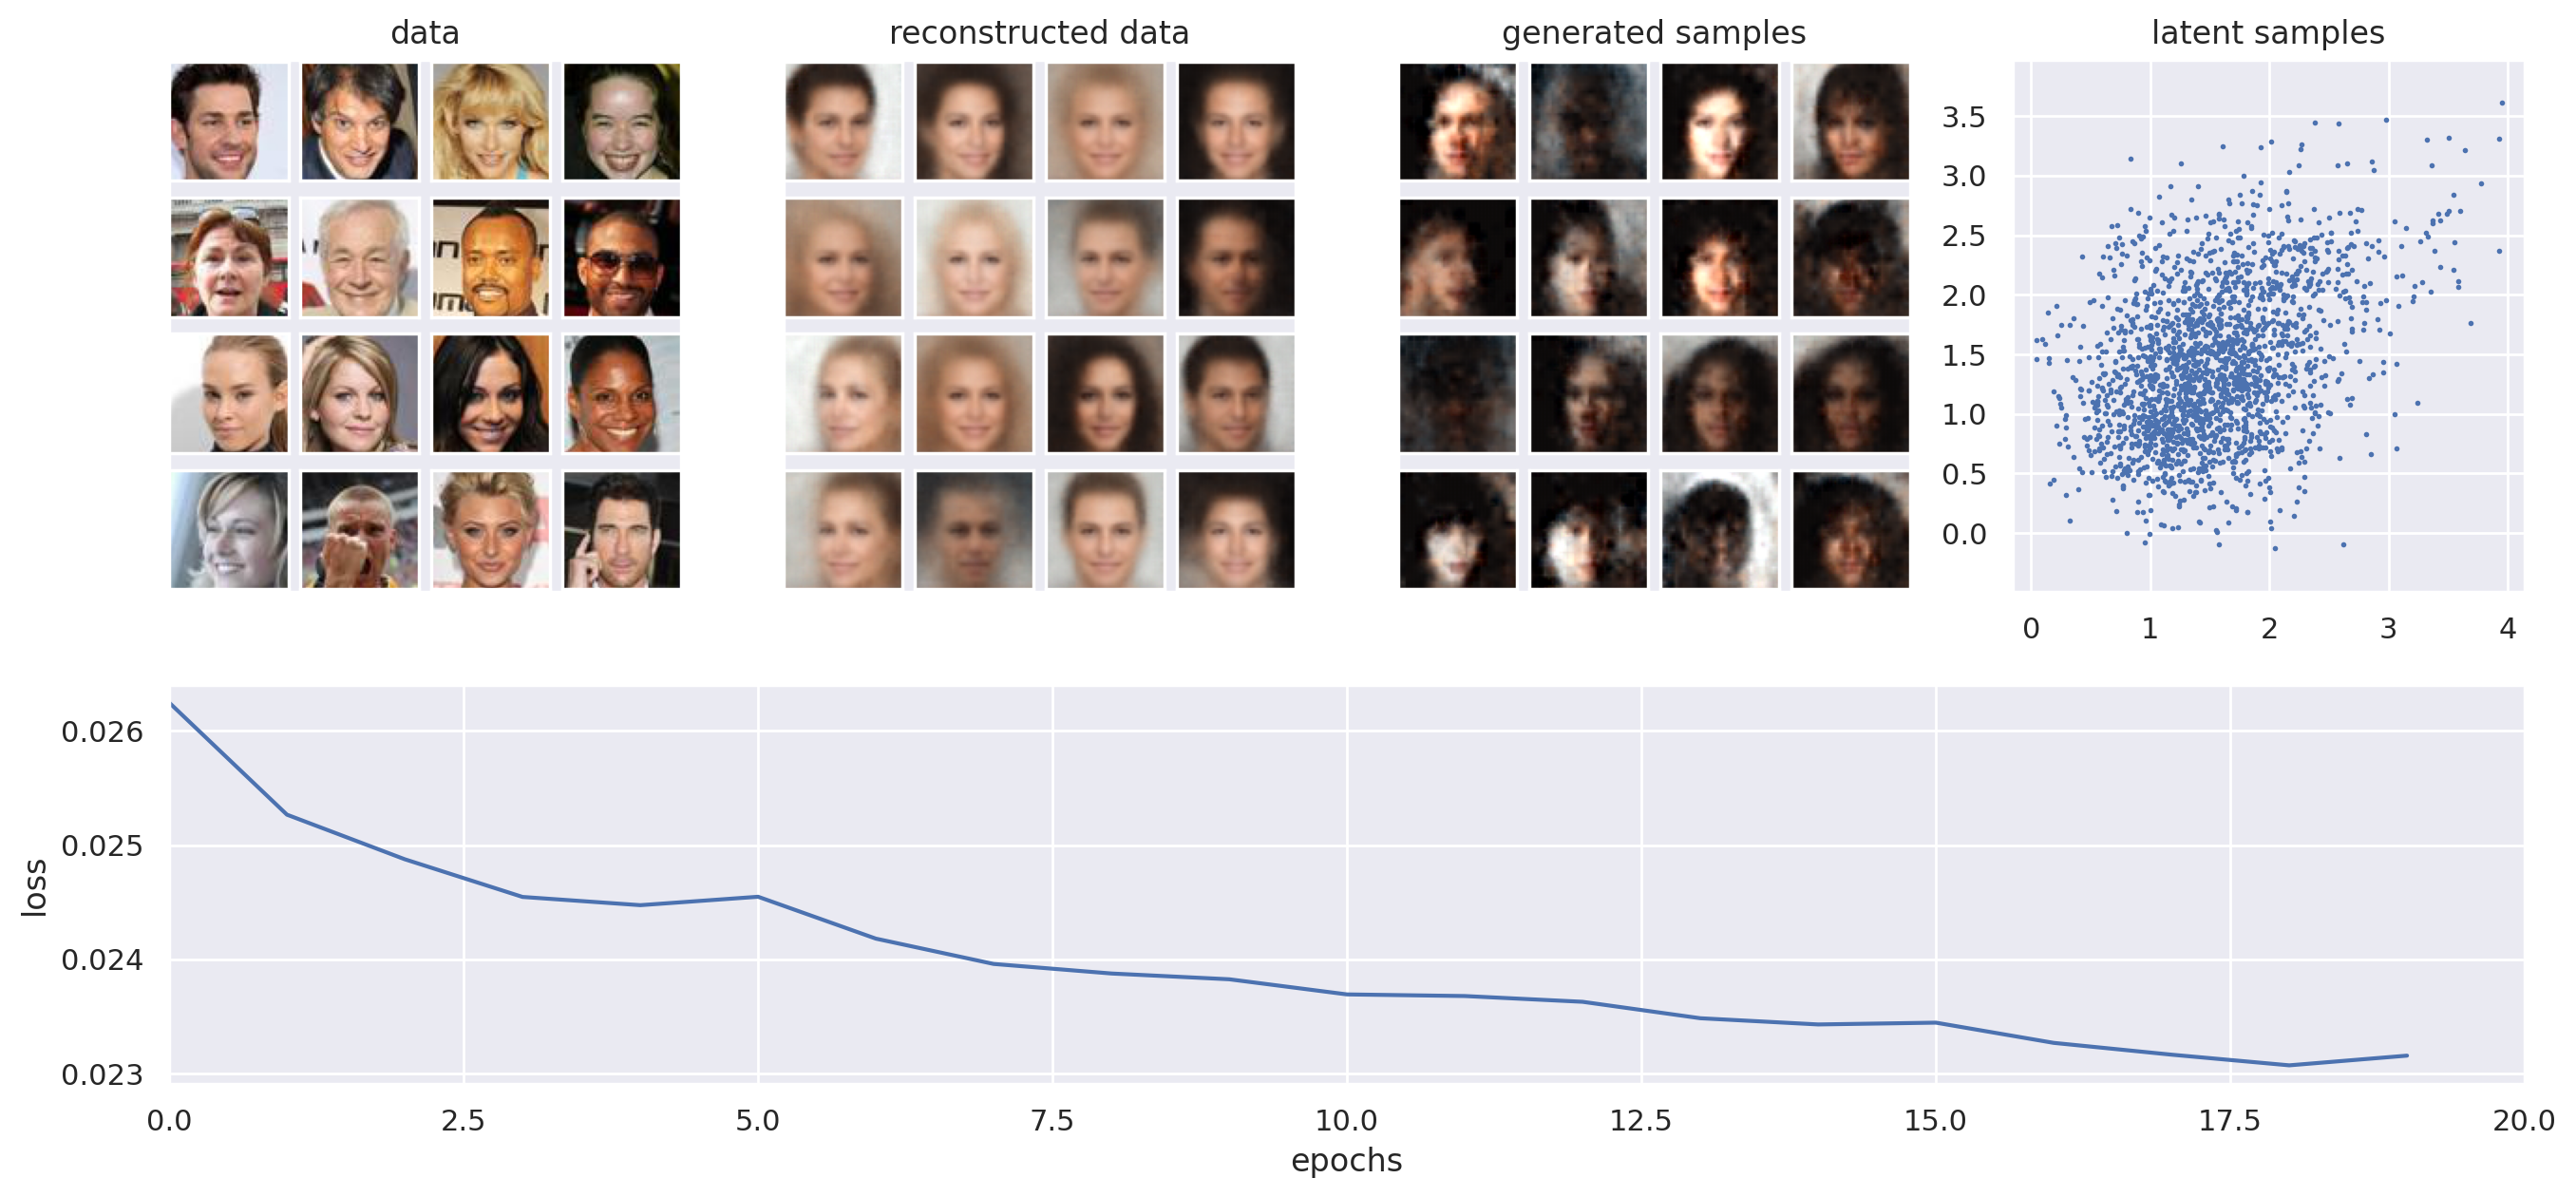

Finished Training. Time taken: 3394.86s
Saving weights to: /kaggle/working/celeba_ae10d.pt


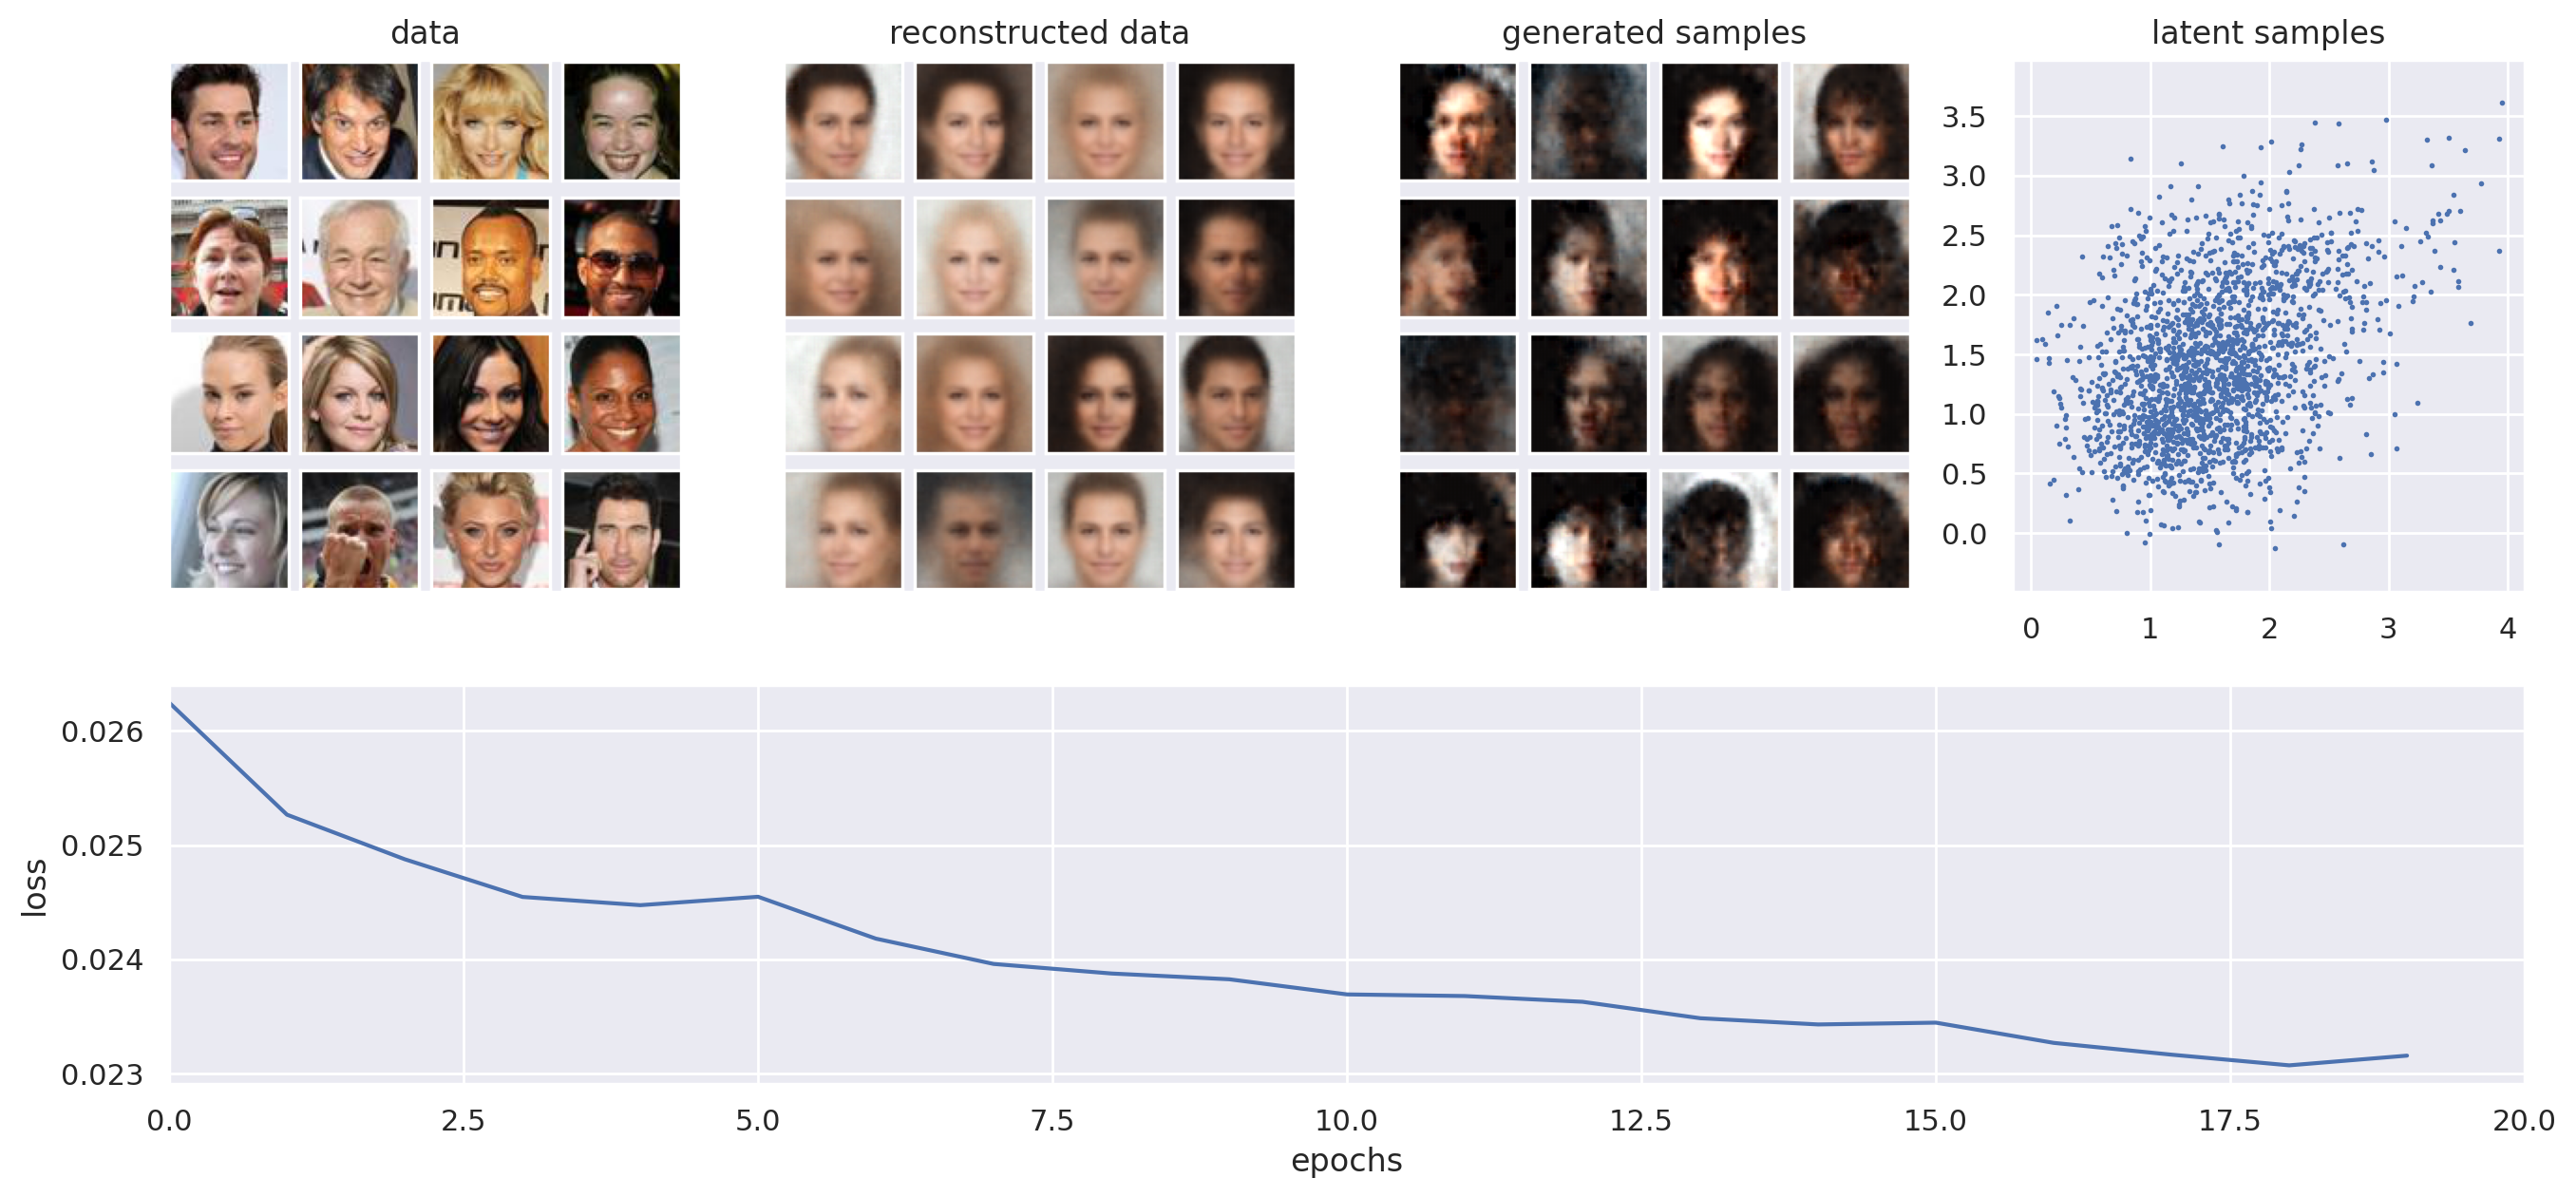

In [15]:
# Run the training! Important: Reset your model and optimizers before starting the training. 
# remember that this can take anywhere between 15 mins to the heat death of the universe depending on the size of your model, 
# so be patient (and if you're looking like you're on the heat death of the unvierse side of things, maybe make your model smaller).

# to save model weights after training, define a path to store the weights
weights_path = '/kaggle/working/celeba_ae10d.pt'
#assert not os.path.exists(weights_path), f"{weights_path} already exists, choose a new name unless you wish to overwrite weights"

# Start training!
tic = time.time()
model = train_autoencoder(model, train_loader, val_loader, optimizer, num_epochs, seed=3)
toc = time.time()
print(f"Finished Training. Time taken: {toc-tic:.2f}s")

# save weights after training
print(f"Saving weights to: {weights_path}")
torch.save(model.state_dict(), weights_path)

In [16]:
class Decoder(nn.Module):
    """This is the decoder class for your VAE. The objective of the decoder is to take a sample `z` of size
    (N, latent_features) and transform it to a tensor (image) of size (N, 3, 64, 64), where N=batch_size.
    
    You can use any combination of `nn.Linear` and `nn.ConvTranspose2d` layers here, with `nn.ReLU` activations
    in between (everywhere but the end). We used 2 Linear layers followed by 4 ConvTranspose2d layers in our 
    final testing (that is input -> linear -> linear -> conv -> conv -> conv -> conv -> out), but you should start with something 
    simpler that you can test as long as the input and output shapes are accounted for. 
    
    Make sure you `unflatten` the output of a linear layer before passing it as an 
    input to conv2d layer (if any).
    
    Tip: Writing the expected input and output shapes after each layer in the comments helps.
    """
    def __init__(self, output_features, latent_features):
        super(Decoder, self).__init__()
        self.output_features = output_features  # this is the product of output dimensions, not the shape
        self.latent_features = latent_features
        # TODO: initialize the Decoder network
        ####################################################
        # Linear layers to map from latent space to image space
        self.fc1 = nn.Linear(latent_features, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc3 = nn.Linear(512, 1024)
        self.fc4 = nn.Linear(1024, 4096)

        # Transposed Convolutional layers to upsample the image
        self.conv1 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.conv2 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.conv3 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.conv4 = nn.ConvTranspose2d(32, 3, 4, 2, 1)

        self.relu = nn.ReLU()
        
        

        ####################################################

    def forward(self, z):
        # TODO: Define the forward pass for the network,
        # you can reuse 'z' for the output
        ####################################################
        z = self.relu(self.fc1(z))
        z = self.relu(self.fc2(z))
        z = self.relu(self.fc3(z))
        z = self.relu(self.fc4(z))
        z = z.view(-1, 256, 4, 4)  # Unflatten the tensor

        z = self.relu(self.conv1(z))
        z = self.relu(self.conv2(z))
        z = self.relu(self.conv3(z))
        z = self.conv4(z)
        
        
        
        
        ####################################################
        return z

In [17]:
# let's test if it worked
output_features = 3*64*64
latent_features = 2
# initialize decoder
decoder = Decoder(output_features, latent_features)
# sample input
z = torch.rand((100, 2))
# forward pass through decoder
x_logit = decoder(z)
print(f"Input shape: {z.shape} \nOutput shape: {x_logit.shape}")
print("The expected size of the output is (batch_size, 3, 64, 64). Is it?")

Input shape: torch.Size([100, 2]) 
Output shape: torch.Size([100, 3, 64, 64])
The expected size of the output is (batch_size, 3, 64, 64). Is it?


In [18]:
class Encoder(nn.Module):
    """This is the encoder class for your VAE. The objective of the decoder is to take an image
    of size (3, 64, 64) as input and produce: (a) `mean` vector of shape (N, latent_features), 
    (b) `std` vector of shape (N, latent_features), and (c) a 'reparameterized' sample from the 
    distribution using the generated mean and std, of shape (N, latent_features).
    
    In general, the architecture is designed to mirror the decoder, but it's not necessary.
    We recommend you start with a combination of 'nn.Conv2d' and 'nn.Linear' with `nn.ReLU` in 
    between in the inverse order to your decoder. We used four Conv2d layers, followed by a Linear
    layer that feeds another Linear layer for the `mean` and `std` each. Aka the last encoder layers
    share the same input. You can start with something simpler as long as you still have one linear
    layer each for mean and std at the end.
    
    Caveat: the standard deviation (std) of a distribution needs to be strictly > 0, and therefore
    we assume the `std` generated is log(std) and therefore needs to be exponentiated before 
    drawing a sample. We take care of this for you.
    """
    def __init__(self, input_features, latent_features):
        super(Encoder, self).__init__()
        self.input_features = input_features  # this is the product of input dimensions, not the shape
        self.latent_features = latent_features
        # TODO: initialize the Encoder network
        # remember to have two linear layers at the end for mean (`fc_mu`) and variance (`fc_logvar`)
        ####################################################
        #inverse order of decoder
        
         #inverse order of decoder
        self.conv1 = nn.Conv2d(3, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.conv4 = nn.Conv2d(128, 256, 4, 2, 1)
        self.fc_mu = nn.Linear(4096, latent_features)
        self.fc_logvar = nn.Linear(4096, latent_features)
        ####################################################

    def forward(self, x):
        # TODO: Define the forward pass for the network, until the layer for mean and var computation
        # you can reuse 'x' for this part of the output
        ####################################################
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = x.view(x.size(0), -1)
        

        ####################################################
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        std = (logvar * .5).exp()
        
        # TODO: You'll need to complete the rsample function below for this to work
        z0 = self.rsample(mu, std)
        
        return z0, mu, logvar
    
    def rsample(self, mu, std):
        """This function takes a mean and std vector, to draw a reparameterized sample from a
        standard normal distribution.

        Inputs:
            mu (torch.Tensor): mean vector of shape (N, latent_features)
            std (torch.Tensor): std vector of shape (N, latent_features)
        Outputs:
            z (torch.Tensor): Reparameterized sample with mean `mu` and standard deviation `std`
                                of shape (N, latent_features)
        """
        # TODO: Create a reparameterized sample using mu and std
        # That is, generate a normal random sample (mean 0, std 1) using torch.randn_like()
        # Then transform it using mu and std to be the correct 
        ####################################################
        
        eps = torch.randn_like(mu)
        # Scale by std
        z = eps * std
        # Shift by mean
        z = z + mu
        
        ####################################################
        return z

In [19]:
# let's test if it worked
input_features = 3*64*64
latent_features = 2
# initialize encoder
encoder = Encoder(input_features, latent_features)
# sample input
x = torch.rand((100, 3, 64, 64))
# forward pass through encoder
z, mu, logvar = encoder(x)
print(f"Input shape: {x.shape},\nMean shape: {mu.shape}, Std shape: {logvar.shape}, Z shape: {z.shape}")
print("The expected size of the mean, std, and z vectors is (batch_size, 2). Is it?")

Input shape: torch.Size([100, 3, 64, 64]),
Mean shape: torch.Size([100, 2]), Std shape: torch.Size([100, 2]), Z shape: torch.Size([100, 2])
The expected size of the mean, std, and z vectors is (batch_size, 2). Is it?


In [20]:
class VAE(nn.Module):
    """This class ties together the Variational Encoder and Decoder that you defined and computes the
    requisite loss functions, aka the reconstruction loss and KL loss. This will be your final model,
    and although the code is provided, please take a look to see if you understand what's happening here.
    
    Params:
        input_features   : the total number of input features to the network (int)
        latent_features  : the dimensionality of the latent code (compressed representation) (int)

    Inputs:
        X                : The input image. shape (N, 3, 64, 64)
        
    Outputs (dict):
        z                : The reparameterized sample produced by encoder. shape (N, latent_features)
        x_recon          : The reconstructed version of input X. shape (N, 3, 64, 64)
        loss             : the sum of recon_loss and kl_loss. (float)
    """
    def __init__(self, input_features, latent_features):
        super(VAE, self).__init__()
        self.input_features = self.output_features = input_features
        self.latent_features = latent_features
        self.encoder = Encoder(self.input_features, self.latent_features)
        self.decoder = Decoder(self.output_features, self.latent_features)

        # the following line computes the reconstruction loss assuming a bernoulli prior, and
        # therefore uses binary cross entropy instead of mean squared error that you've seen before.
        self.recon_loss = nn.BCEWithLogitsLoss(reduction='sum')  # bernoulli noise

        # the following line computes the KL divergence between a standard normal and a
        # normal distribution with mean `mu` and variance `logvar`.
        self.kl_loss = lambda mu, logvar: -0.5 * (1 + logvar - mu ** 2 - logvar.exp()).sum()

    def forward(self, x):
        num_samples = x.size(0)
        z, mu, logvar = self.encoder(x)
        x_logit = self.decoder(z)
        recon_loss = self.recon_loss(x_logit, x) / num_samples
        kl_loss = self.kl_loss(mu, logvar) / num_samples
        loss = recon_loss + kl_loss

        return {
            'z': z.detach(),  # this contains the latent encodings that we'll use to plot
            'x_recon': torch.sigmoid(x_logit.detach()),  # this contains the reconstructed image
            'loss': loss,  # this is the loss that we'll use to train the network through backprop
        }

In [21]:
# initialize model and count number of trainable parameters
input_features = 3*64*64
latent_features = 2
model = VAE(input_features, latent_features)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"No. of trainable parameters: {num_params}")
print("Warning! If your model has > 0.5M parameters, it might take really long to train!")

No. of trainable parameters: 6252487
Warning! If your model has > 0.5M parameters, it might take really long to train!


Test image input:


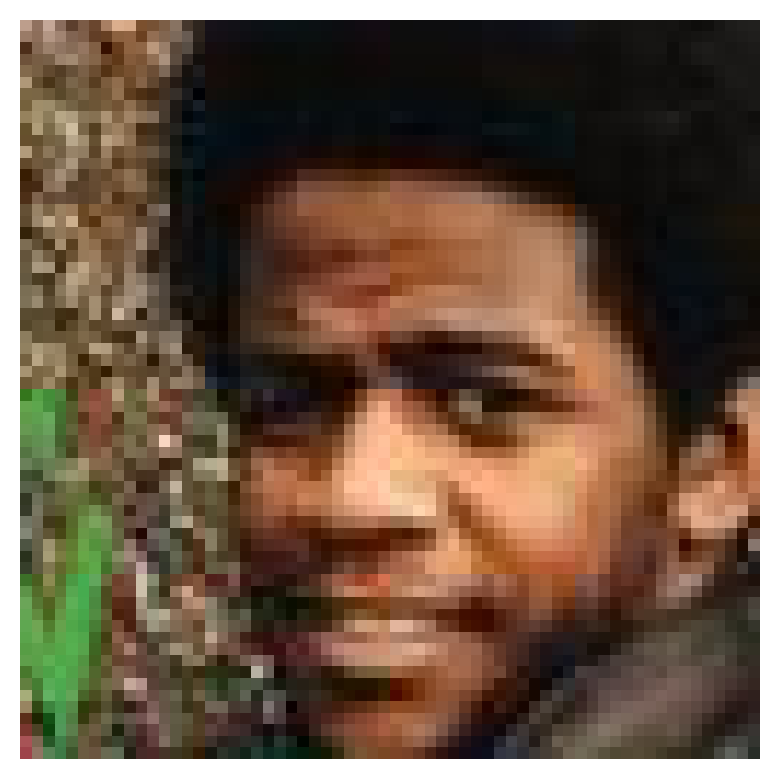

Test image reconstruction:


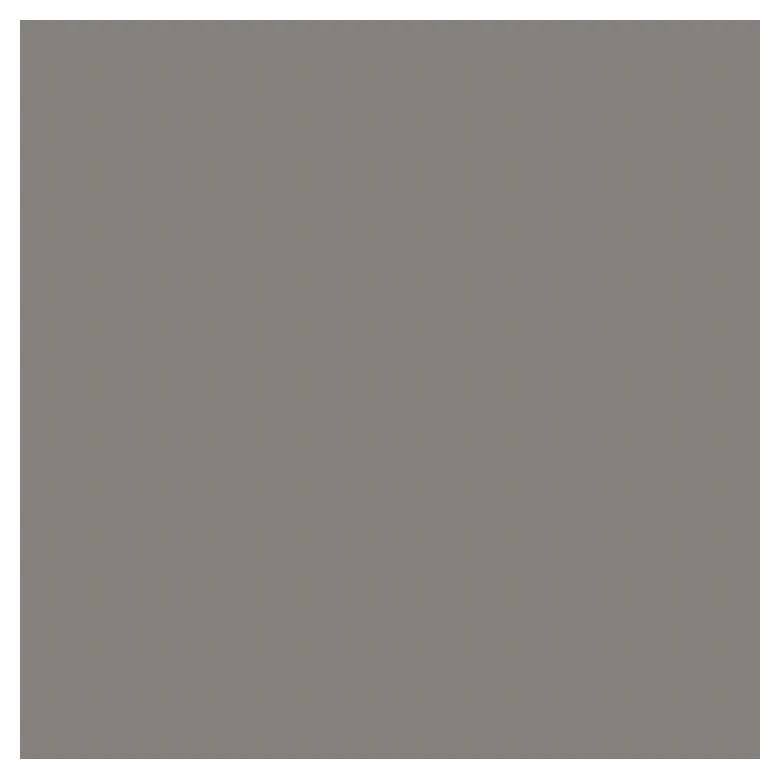

In [22]:
# Shows the prediction of the autoencoder without training

test_image = data[random.randint(0, len(data))]

print("Test image input:")
plot_image(test_image)

outputs = model(test_image.unsqueeze(0))

print("Test image reconstruction:")
plot_image(outputs['x_recon'].squeeze())

In [23]:
# Model and training parameters
input_features = 3 * 64 * 64  # do not change
# start with these parameters, and then play around with them
#############################################
latent_features = 2
lr = 1e-3
batch_size = 128
num_epochs = 50
#############################################

# initialize model and move it to GPU
model = VAE(input_features, latent_features)
model = model.to(device)

# Initialize dataset and dataloaders
# for this HW, we're gonna use a subset of the training data as test. This is a really bad idea in practice,
# but sufficient for the purposes of this HW.
data = CelebA_50k('/kaggle/input/50k-celeba-dataset-64x64/50k', transform=transforms.ToTensor())
train_loader = DataLoader(data, batch_size=batch_size, num_workers=4, shuffle=True, pin_memory=True)
val_loader = DataLoader(data, batch_size=2000, num_workers=1, shuffle=False, pin_memory=True)

optimizer = optim.Adam(model.parameters(), lr=lr)


In [24]:
# Let's take things for a spin
# This checks that your model, loss and optimizer are valid
print("BEFORE GRADIENT STEP:")
test_image = data[random.randint(0, len(data))]
# we now need to move the input to the same device as the model (aka GPU)
test_image = test_image.unsqueeze(0).to(device)
output = model(test_image)

optimizer.zero_grad() # Sets the gradient to 0 so that gradients don't stack together

loss_before = output['loss']
print("loss: ", loss_before.item())

loss_before.backward() # This gets the gradient of the loss function w.r.t all of your model's params

print()
print("AFTER GRADIENT STEP:")
optimizer.step() # This takes the step to train

output = model(test_image)

loss_after = output['loss']
print("loss: ",loss_after.item())

print()
print("Difference in loss:", (loss_before - loss_after).item())
print("This should be some positive number to say we reduced loss")

BEFORE GRADIENT STEP:
loss:  8577.5625

AFTER GRADIENT STEP:
loss:  8562.3896484375

Difference in loss: 15.1728515625
This should be some positive number to say we reduced loss


In [25]:
def train_vae(model, train_loader, val_loader, optimizer, epochs=1, seed=42):
    """Updates the parameters of the given model using the optimizer of choice to
    reduce the given loss_function. This will iterate over the dataloader `epochs` times
    training on each batch of images.
    
    There are 4 steps you need to complete here:
        (1) Reset the optimizer, so that gradients are zeroed out. Hint: use .zero_grad()
        (2) Forward pass: call the model on a batch of inputs `batch_x`.
        (3) Backward pass: use the `loss` key in the returned dict. Hint: use .backward()
        (4) Take a step in the direction of the -ve gradient. Hint: use .step()
    """
    torch.manual_seed(seed)
    if cuda:
        torch.cuda.manual_seed(seed)

    # set up tracking parameters
    plot_interval = 1
    history = {'loss': []}
    vis = Visualizer(
        figsize=(16, 7),
        loss_xlim=(0, epochs),
        plot_interval=plot_interval,
    )
    
    # run the training loop
    print("Started training... (first epoch can take a while)")
    for epoch in range(epochs):
        model = model.train()  # set the model to training mode
        for batch_idx, batch_x in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")):
            batch_x = batch_x.to(device)  # move the input to the correct device
            
            optimizer.zero_grad()  # zero the optimizer so gradients don't stack
            loss_dict = model(batch_x)  # run forward pass
            loss_dict['loss'].backward()  # run backward pass
            optimizer.step()  # take a step in the direction that minimizes loss


        # validation
        if epoch % plot_interval == 0:
            test_vae(model, val_loader, history, vis)
            
    return model

@torch.no_grad()  # this makes sure that we don't accumulate gradients during testing phase
def test_vae(model, val_loader, history, vis):
    model = model.eval()  # set the model to evaluation mode
    batch_x = next(iter(val_loader)).to(device)  # only use 2000 examples for test
    
    loss_dict = model(batch_x)  # run forward pass on test examples
    
    # record metrics and images for plotting
    history['loss'].append(loss_dict['loss'].item())
    x_recon = loss_dict['x_recon']

    # generate faces -- the cool part
    x_gen = torch.sigmoid(model.decoder(torch.randn_like(loss_dict['z'])))

    # plot the results
    vis.plot(batch_x, x_recon, x_gen, loss_dict['z'].cpu().numpy(), history)

In [ ]:
# to save model weights after training, define a path to store the weights
weights_path = '/kaggle/working/celeba_vae2d.pt'
#assert not os.path.exists(weights_path), f"{weights_path} already exists, choose a new name unless you wish to overwrite weights"

# Start training!
tic = time.time()
model = train_vae(model, train_loader, val_loader, optimizer, num_epochs, seed=3)
toc = time.time()
print(f"Finished Training. Time taken: {toc-tic:.2f}s")

# save weights after training
print(f"Saving weights to: {weights_path}")
torch.save(model.state_dict(), weights_path)

In [ ]:
# define your model, optimizers, and run the train loop here with a bigger number of `latent_features`
# model and training params
input_features = 3 * 64 * 64  # do not change
# play around with these parameters
#############################################
latent_features = 15
lr = 1e-3
batch_size = 128
num_epochs = 20
#############################################

# initialize model and move it to GPU
model = VAE(input_features, latent_features)
model = model.to(device)

# initialize optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)

# to save model weights after training, define a path to store the weights
weights_path = '/kaggle/working/your_best_vae_model.pt'
#assert not os.path.exists(weights_path), f"{weights_path} already exists, choose a new name unless you wish to overwrite weights"

# Start training!
tic = time.time()
model = train_vae(model, train_loader, val_loader, optimizer, num_epochs, seed=3)
toc = time.time()
print(f"Finished Training. Time taken: {toc-tic:.2f}s")

# save weights after training
print(f"Saving weights to: {weights_path}")
torch.save(model.state_dict(), weights_path)

In [ ]:
# specify the path to the weights of the best model you trained
# weights_path = '/kaggle/working/2d_celeba_vae20d.pt'
weights_path = '/kaggle/working/your_best_vae_model.pt'

if(os.path.exists(weights_path)):
    model.load_state_dict(torch.load(weights_path))
    model = model.eval().to(device)
    print("Loaded pretrained VAE")
else:
   print(f"No weights found at: {weights_path}")

In [ ]:
# TODO: set two dimensions that you'd like to control in your latent space
# Note: dim1, dim2 has to be in the range [0, latent_features-1]
# For example the setting below would allow you to control the first 2 features of your latent space
#############################################
dim1, dim2 = 2, 3
#############################################

model = model.eval()

@torch.no_grad()
def generate(Z,decoder):
    """Function to generate an image using the variational decoder given a latent code

        Inputs:
            Z (torch.Tensor) : latent code tensor of size (1, latent_features)
        Outputs:
            x_gen (torch.Tensor) : generated image tensor of size (1, 3, 64, 64)
    """
    Z = Z.to(device)
    x_gen = torch.sigmoid(decoder(Z)).cpu()
    return(x_gen)

def f(z1, z2):
    plt.grid(False)
    # start with a latent vector of all zeros
    z = torch.zeros(latent_features)
    z[dim1], z[dim2] = z1, z2
    x = generate(z.unsqueeze(0), model.decoder).squeeze().permute(1, 2, 0).numpy()
    plt.imshow(x, interpolation='nearest', vmin=0,vmax=1)
    plt.show()

interact(f,z1=(-4.0, 4.0), z2=(-4.0, 4.0), continuous_update=False);